<a href="https://colab.research.google.com/github/andiunsia/DataScience_240401010009_Andi/blob/main/Pertemuan4_Andi_240401010009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
Nama : Andi

NIM : 240401010009

Kelas : IF204

---

# **Latihan Pertemuan 4**

# Langkah 1: Load & Inspect Dataset

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

# Langkah 2: Statistik Deskriptif Lengkap

In [ ]:
for col_name in df.select_dtypes(include='number').columns:
  col = df[col_name]

  print(f'\n=== {col_name} ===')
  print(f' Mean : {col.mean():.3f}')
  print(f' Median : {col.median():.3f}')
  print(f' Std Dev : {col.std():.3f}')
  print(f' Skewness : {col.skew():.3f}')
  print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


# Langkah 3: Analisis Distribusi (Histogram + KDE)

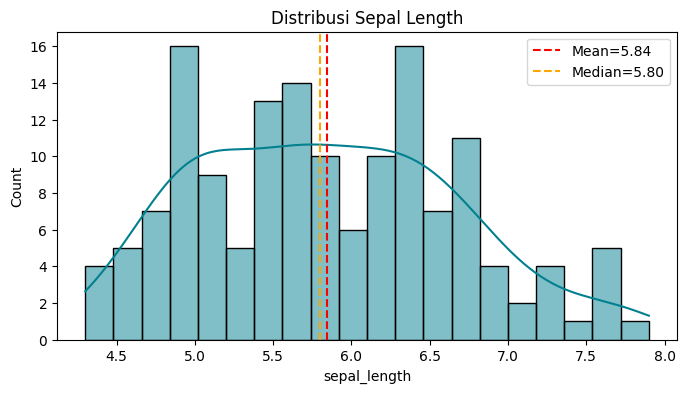

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
          color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
         linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
         linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

# Langkah 4: Boxplot per Spesies

/tmp/ipykernel_1943/3613019602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1943/3613019602.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


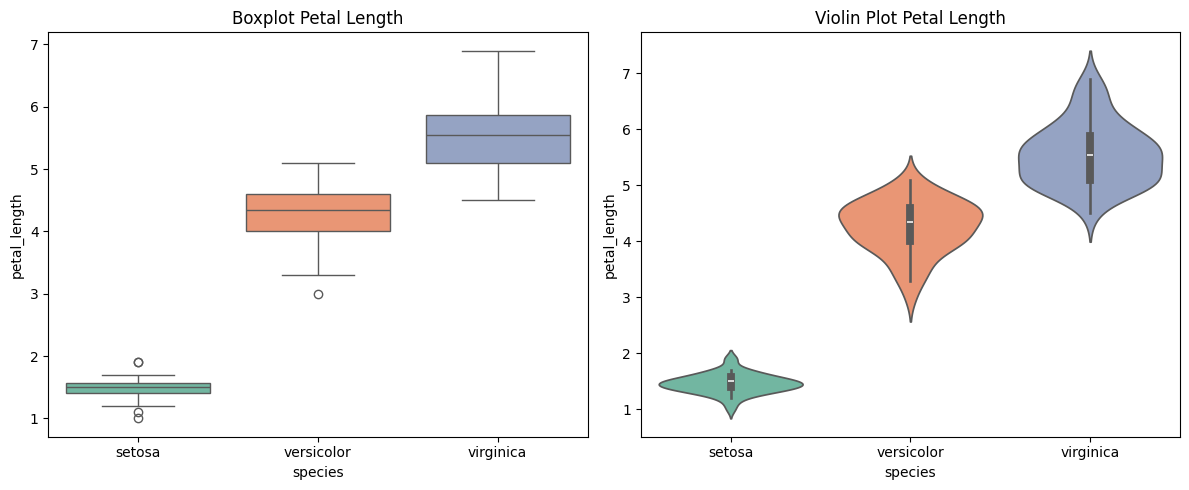

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout(); plt.show()

# Langkah 5: Matriks Korelasi Pearson

In [ ]:
import numpy as np

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


# Langkah 6: Scatter Plot & Heatmap

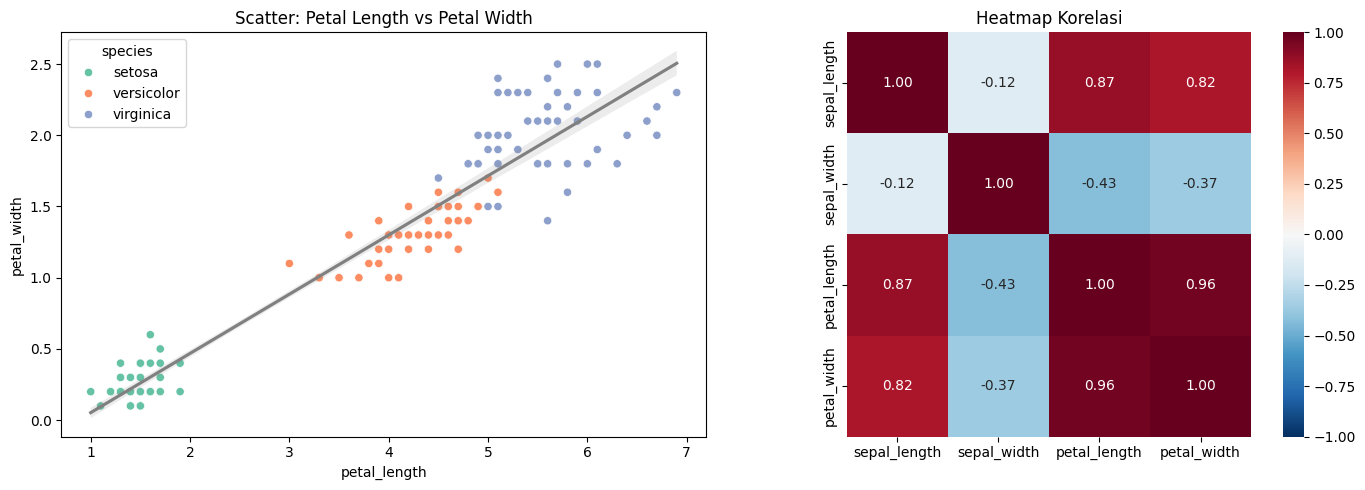

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns

df = sns.load_dataset('iris')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

# **Kesimpulan**
**Analisis Statistik dan Eksplorasi Data Iris**

Analisis statistik deskriptif dan eksplorasi data (EDA) pada dataset Iris dilakukan menggunakan Pandas, SciPy, Matplotlib, dan Seaborn, untuk memahami karakteristik data, distribusi variabel, serta hubungan antarvariabel melalui pendekatan statistik dan visualisasi.

Aktivitas ini memberikan pemahaman tentang dataset Iris melalui pendekatan statistik dan visualisasi. Ditemukan bahwa fitur kelopak bunga (petal length dan petal width) memiliki daya pembeda yang sangat kuat antar spesies, dengan korelasi yang hampir sempurna. Analisis ini juga memperkuat pemahaman tentang pentingnya statistik deskriptif dan visualisasi dalam Exploratory Data Analysis (EDA), yang menjadi fondasi sebelum tahapan pemodelan machine learning.


1. Struktur dan Karakteristik Data
      
      Dataset Iris terdiri dari 150 baris dan 5 kolom dan tidak ada nilai hilang, sehingga data siap untuk analisis.

2. Statistik Deskriptif dan Bentuk Distribusi

      Sepal Length: Rata-rata 5.84, median 5.80, distribusi hampir simetris (skewness 0.315), dengan variasi yang relatif kecil (std 0.828).

      Sepal Width: Rata-rata 3.06, median 3.00, distribusi agak menceng ke kanan (skewness 0.319).

      Petal Length & Width: Keduanya memiliki variasi yang lebih besar (std masing-masing 1.765 dan 0.762) dengan distribusi yang sedikit menceng ke kiri (skewness negatif). Nilai kurtosis negatif menunjukkan distribusi yang lebih flat (kurang runcing) dibanding distribusi normal.

3. Visualisasi Distribusi

      Histogram dengan KDE pada sepal length menunjukkan distribusi yang mendekati normal, dengan mean dan median yang hampir berimpit. Hal ini mengindikasikan tidak adanya outlier ekstrem pada fitur tersebut.

4. Perbandingan Antar Spesies

      Boxplot dan Violin Plot pada petal length menunjukkan perbedaan yang sangat jelas antar spesies:

      Setosa memiliki petal length terpendek (1.0–1.9 cm).

      Versicolor berada di rentang menengah (3.0–5.1 cm).

      Virginica memiliki petal length terpanjang (4.5–6.9 cm).

      Pola serupa juga terlihat pada petal width, mengindikasikan bahwa kedua fitur ini sangat diskriminatif untuk klasifikasi spesies.

5. Analisis Korelasi Pearson

      Matriks korelasi menunjukkan hubungan yang sangat kuat antara petal length dan petal width (r = 0.963), serta keduanya berkorelasi positif dengan sepal length (r ≈ 0.82–0.87).

      Sepal width berkorelasi negatif lemah dengan ketiga fitur lainnya, menunjukkan bahwa fitur ini kurang berkontribusi terhadap pembeda spesies.

      Heatmap memvisualisasikan korelasi tersebut dengan jelas, mengonfirmasi bahwa petal measurements adalah prediktor utama dalam identifikasi spesies Iris.

6. Keterampilan Praktis yang Diasah

      Penggunaan fungsi statistik seperti mean(), median(), std(), skew(), dan kurtosis().

      Visualisasi distribusi dengan histogram + KDE.

      Perbandingan antarkelompok menggunakan boxplot dan violin plot.

      Analisis korelasi dengan corr() dan visualisasi heatmap.

      Interpretasi statistik deskriptif dan korelasi dalam konteks biologi dan klasifikasi.


